In [12]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio

In [13]:


# Find the project root automatically.
# This works whether the notebook is opened from the
# project root or from the notebooks folder.

def find_project_root():
    for directory in [Path.cwd(), *Path.cwd().parents]:
        if (directory / "Data").exists() and (directory / "Results").exists():
            return directory
    
    raise FileNotFoundError(
        "Could not find the project root. "
        "Make sure the Data/ and Results/ folders are present."
    )


PROJECT_DIR = find_project_root()

# Main data directory
DATA_DIR = PROJECT_DIR / "Data" / "Sen1Floods11_raw"

# Sen1Floods11 data directory
base_dir = DATA_DIR / "v1.1" / "data"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATA_DIR)

Project directory: /Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub
Dataset directory: /Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub/Data/Sen1Floods11_raw


In [14]:
# All TIFF files within the raw Sen1Floods11 dataset:

tif_files = list(DATA_DIR.rglob("*.tif"))

print("Total Raw Dataset Raster Images:")
print(len(tif_files))

Total Raw Dataset Raster Images:
0


In [15]:

# Example Sentinel-1 SAR image:

file = (DATA_DIR/ "v1.1"/ "data"/ "flood_events"/ "HandLabeled"/ "S1Hand"/ "Mekong_922373_S1Hand.tif")

print(file)

/Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/S1Hand/Mekong_922373_S1Hand.tif


In [16]:
mask_file = (DATA_DIR/ "v1.1"/ "data"/ "flood_events"/ "HandLabeled"/ "LabelHand"/ "Mekong_382276_LabelHand.tif")

print(mask_file)

/Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/LabelHand/Mekong_382276_LabelHand.tif


In [17]:
# Define the Sentinel-1 SAR and label directories.

DATA_PATH = DATA_DIR / "v1.1" / "data"

S1_PATH = DATA_PATH / "flood_events" / "HandLabeled" / "S1Hand"
LABEL_PATH = DATA_PATH / "flood_events" / "HandLabeled" / "LabelHand"

print("SAR directory:", S1_PATH)
print("Label directory:", LABEL_PATH)

SAR directory: /Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/S1Hand
Label directory: /Users/archiewilliamhulse/Desktop/MSc Dissertation GitHub/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/LabelHand


In [18]:
# All hand-labelled Sentinel-1 SAR images and corresponding labels:

s1_files = list(S1_PATH.glob("*_S1Hand.tif"))
label_files = list(LABEL_PATH.glob("*_LabelHand.tif"))

print("SAR images:", len(s1_files))
print("Labels:", len(label_files))

SAR images: 0
Labels: 0


In [19]:
import re

s1_dict = {}

for f in s1_files:
    key = re.search(r'_(\d+)_S1Hand', f.name).group(1)
    s1_dict[key] = f


label_dict = {}

for f in label_files:
    key = re.search(r'_(\d+)_LabelHand', f.name).group(1)
    label_dict[key] = f

In [20]:
matches = set(s1_dict.keys()) & set(label_dict.keys())

print("Matching pairs:", len(matches))
print("Example:", list(matches)[:10])

Matching pairs: 0
Example: []


In [21]:
key = list(matches)[0]

s1_file = s1_dict[key]
label_file = label_dict[key]

print(s1_file.name)
print(label_file.name)

IndexError: list index out of range

In [ ]:
with rasterio.open(s1_file) as src:
    sar = src.read(1)

with rasterio.open(label_file) as src:
    mask = src.read(1)


print("SAR shape:", sar.shape)
print("Mask shape:", mask.shape)

print("SAR range:", sar.min(), sar.max())
print("Mask values:", np.unique(mask))

SAR shape: (512, 512)
Mask shape: (512, 512)
SAR range: -31.793438 6.5478806
Mask values: [-1  0  1]


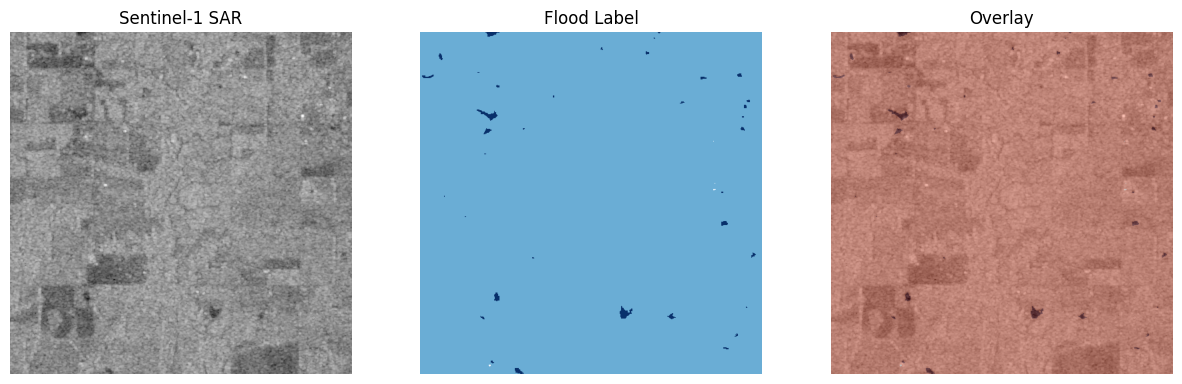

In [ ]:

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(sar, cmap="gray")
plt.title("Sentinel-1 SAR")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="Blues")
plt.title("Flood Label")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sar, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.show()

In [ ]:
# number of SAR images should be equal to hand labeled:
data_path = Path(DATA_DIR) / "v1.1" / "data"

s1_path = data_path / "flood_events" / "HandLabeled" / "S1Hand"
label_path = data_path / "flood_events" / "HandLabeled" / "LabelHand"

print("SAR images:", len(list(s1_path.glob("*S1Hand.tif"))))
print("Labels:", len(list(label_path.glob("*LabelHand.tif"))))

SAR images: 446
Labels: 446


In [ ]:
from collections import Counter

events = []

for file in s1_path.glob("*S1Hand.tif"):
    event = file.stem.split("_")[0]
    events.append(event)

event_counts = Counter(events)

print("Number of flood events:", len(event_counts))

for event, n in sorted(event_counts.items()):
    print(f"{event:15} {n}")

Number of flood events: 11
Bolivia         15
Ghana           53
India           68
Mekong          30
Nigeria         18
Pakistan        28
Paraguay        67
Somalia         26
Spain           30
Sri-Lanka       42
USA             69


In [ ]:

flood = 0
background = 0
ignore = 0

for file in label_path.glob("*LabelHand.tif"):

    with rasterio.open(file) as src:
        mask = src.read(1)

    flood += np.sum(mask == 1)
    background += np.sum(mask == 0)
    ignore += np.sum(mask == -1)

total = flood + background + ignore

print(f"Flood pixels      : {flood:,}")
print(f"Background pixels : {background:,}")
print(f"Ignore pixels     : {ignore:,}")

print()

print(f"Flood %      : {100*flood/total:.2f}")
print(f"Background % : {100*background/total:.2f}")
print(f"Ignore %     : {100*ignore/total:.2f}")

Flood pixels      : 10,705,605
Background pixels : 90,277,709
Ignore pixels     : 15,932,910

Flood %      : 9.16
Background % : 77.22
Ignore %     : 13.63


In [ ]:
#calculate the percentage of flooded pixels in each image.

coverage = []

for file in label_path.glob("*LabelHand.tif"):

    with rasterio.open(file) as src:
        mask = src.read(1)

    valid = (mask != -1)

    if np.sum(valid) == 0:
        continue

    flood_fraction = np.sum(mask == 1) / np.sum(valid)
    coverage.append(flood_fraction)

coverage = np.array(coverage)

print("Images analysed:", len(coverage))
print(f"Minimum flood coverage : {coverage.min():.3f}")
print(f"Maximum flood coverage : {coverage.max():.3f}")
print(f"Average flood coverage : {coverage.mean():.3f}")
print(f"Median flood coverage  : {np.median(coverage):.3f}")

Images analysed: 441
Minimum flood coverage : 0.000
Maximum flood coverage : 1.000
Average flood coverage : 0.109
Median flood coverage  : 0.026


In [ ]:
print("\nImages with <1% flood :", np.sum(coverage < 0.01))
print("Images with >50% flood:", np.sum(coverage > 0.50))


Images with <1% flood : 148
Images with >50% flood: 27


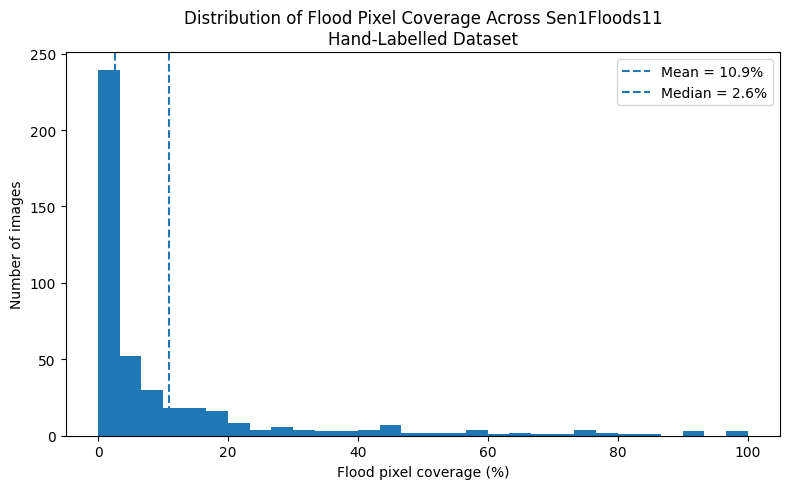

In [ ]:
# Convert flood coverage proportions to percentages
coverage_percent = coverage * 100

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(coverage_percent, bins=30)

# Add mean and median lines
plt.axvline(
    coverage_percent.mean(),
    linestyle="--",
    label=f"Mean = {coverage_percent.mean():.1f}%")

plt.axvline(
    np.median(coverage_percent),
    linestyle="--",
    label=f"Median = {np.median(coverage_percent):.1f}%")

# Labels and title
plt.xlabel("Flood pixel coverage (%)")
plt.ylabel("Number of images")

plt.title(
    "Distribution of Flood Pixel Coverage Across Sen1Floods11\n"
    "Hand-Labelled Dataset")

plt.legend()

plt.tight_layout()
plt.show()

The flood pixel distribution is strongly right-skewed. Most images contain relatively small flooded regions, with the median flood coverage (~2.6%) substantially lower than the mean (~10.9%). This indicates that a small number of highly flooded scenes contribute disproportionately to the overall flood pixel count.

Matched SAR-label pairs: 446


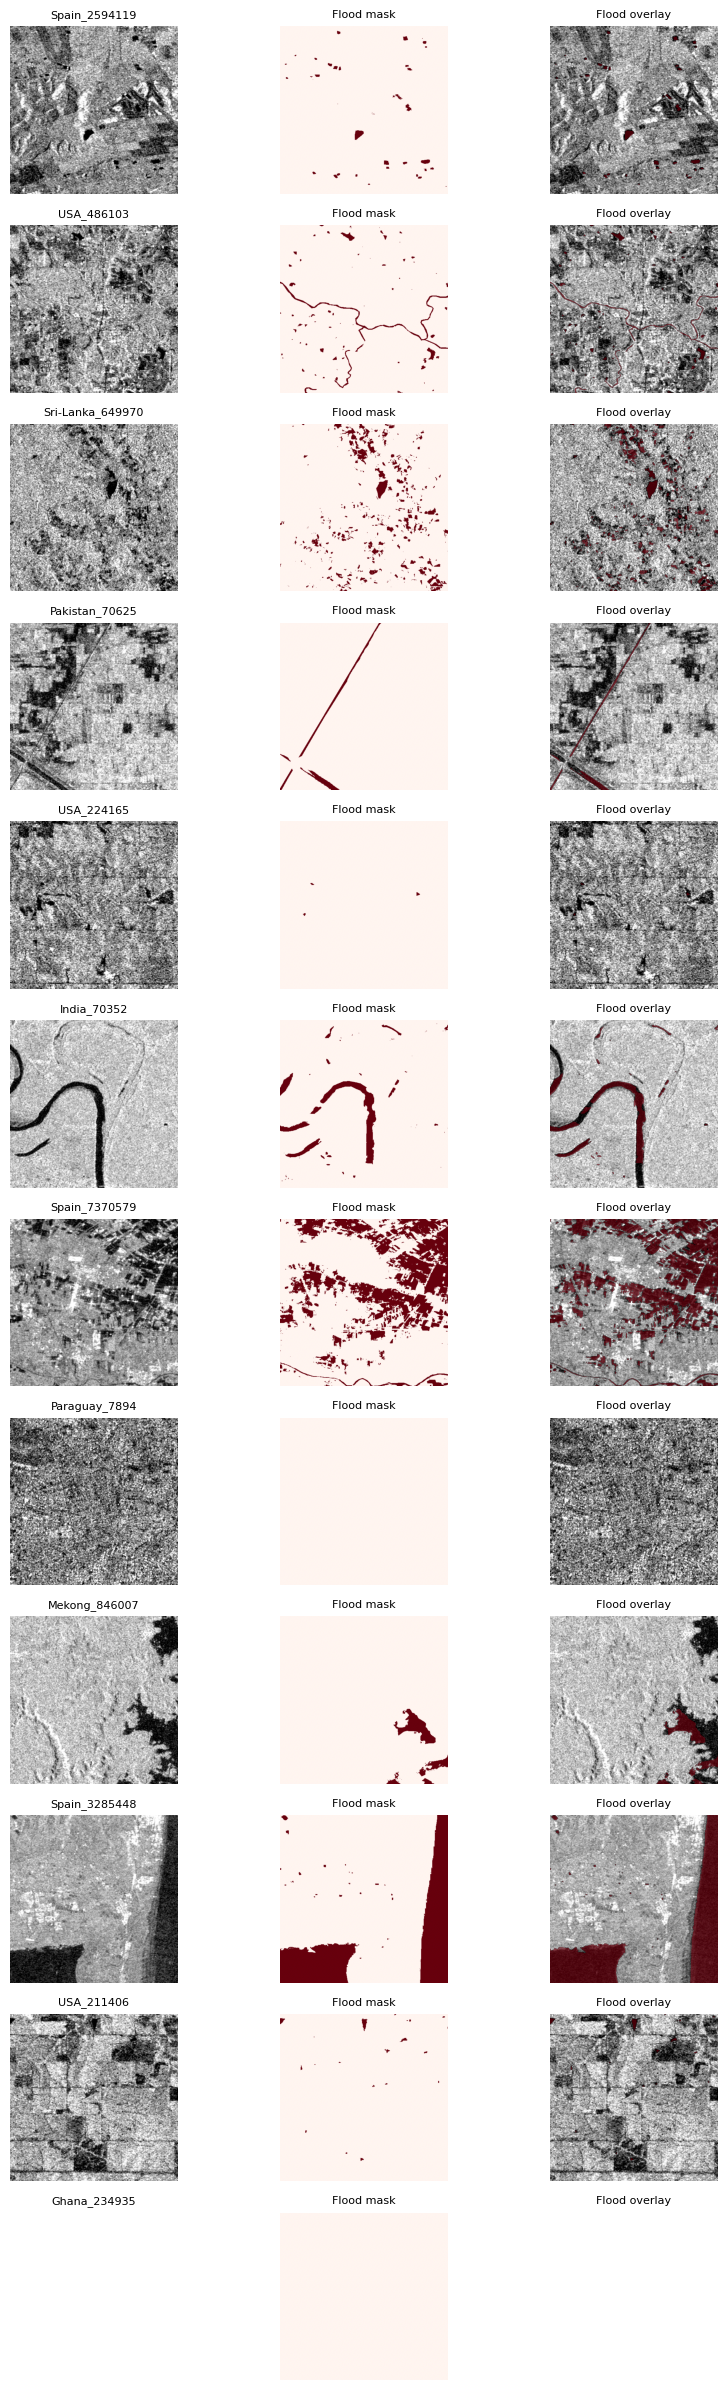

In [ ]:
# Visualise 12 random correctly matched image-mask-overlay examples

import random

# Create dictionaries using the unique chip ID as the key.
# This guarantees that each SAR image is paired with its
# corresponding ground-truth label.

s1_dict = {file.stem.replace("_S1Hand", ""): file for file in s1_path.glob("*_S1Hand.tif")}

label_dict = {file.stem.replace("_LabelHand", ""): file for file in label_path.glob("*_LabelHand.tif")}

# Find chip IDs that have both a SAR image and a label.
common_ids = sorted(set(s1_dict) & set(label_dict))

print("Matched SAR-label pairs:", len(common_ids))

# Randomly select 12 matched chips
random_ids = random.sample(common_ids, 12)

fig, axes = plt.subplots(12, 3, figsize=(9, 24))

for i, chip_id in enumerate(random_ids):

    img_file = s1_dict[chip_id]
    mask_file = label_dict[chip_id]

    # SAR image
    with rasterio.open(img_file) as src:
        img = src.read(1)

    # corresponding ground-truth mask
    with rasterio.open(mask_file) as src:
        mask = src.read(1)

    # Improves the SAR visual contrast
    img_display = np.clip(
        img,
        np.percentile(img, 2),
        np.percentile(img, 98))

    # SAR IMAGE:
    axes[i, 0].imshow(
        img_display,
        cmap="gray")

    axes[i, 0].set_title(
        chip_id,
        fontsize=8)

    axes[i, 0].axis("off")

    # FLOOD MASK:
    axes[i, 1].imshow(
        mask == 1,
        cmap="Reds",
        vmin=0,
        vmax=1)

    axes[i, 1].set_title(
        "Flood mask",
        fontsize=8)

    axes[i, 1].axis("off")

    # SAR + FLOOD OVERLAY:
    axes[i, 2].imshow(
        img_display,
        cmap="gray")

    flood_overlay = np.where(
        mask == 1,
        1,
        np.nan)

    axes[i, 2].imshow(
        flood_overlay,
        cmap="Reds",
        alpha=0.7,
        vmin=0,
        vmax=1)

    axes[i, 2].set_title(
        "Flood overlay",
        fontsize=8)

    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Load the official Sen1Floods11 train/validation/test splits

split_dir = Path(DATA_DIR) / "v1.1" / "splits" / "flood_handlabeled"

train = pd.read_csv(split_dir / "flood_train_data.csv")
valid = pd.read_csv(split_dir / "flood_valid_data.csv")
test = pd.read_csv(split_dir / "flood_test_data.csv")

print("Train:", train.shape)
print("Validation:", valid.shape)
print("Test:", test.shape)

print("\nTrain")
print(train.head())

print("\nValidation")
print(valid.head())

print("\nTest")
print(test.head())

Train: (251, 2)
Validation: (88, 2)
Test: (89, 2)

Train
   Ghana_103272_S1Hand.tif  Ghana_103272_LabelHand.tif
0   Ghana_24858_S1Hand.tif   Ghana_24858_LabelHand.tif
1  Ghana_147015_S1Hand.tif  Ghana_147015_LabelHand.tif
2  Ghana_953791_S1Hand.tif  Ghana_953791_LabelHand.tif
3  Ghana_154838_S1Hand.tif  Ghana_154838_LabelHand.tif
4  Ghana_134751_S1Hand.tif  Ghana_134751_LabelHand.tif

Validation
     Ghana_5079_S1Hand.tif    Ghana_5079_LabelHand.tif
0  Ghana_895194_S1Hand.tif  Ghana_895194_LabelHand.tif
1  Ghana_868803_S1Hand.tif  Ghana_868803_LabelHand.tif
2  Ghana_142312_S1Hand.tif  Ghana_142312_LabelHand.tif
3  Ghana_234935_S1Hand.tif  Ghana_234935_LabelHand.tif
4  Ghana_132163_S1Hand.tif  Ghana_132163_LabelHand.tif

Test
    Ghana_313799_S1Hand.tif   Ghana_313799_LabelHand.tif
0  Ghana_1078550_S1Hand.tif  Ghana_1078550_LabelHand.tif
1    Ghana_97059_S1Hand.tif    Ghana_97059_LabelHand.tif
2   Ghana_359826_S1Hand.tif   Ghana_359826_LabelHand.tif
3   Ghana_319168_S1Hand.tif   Ghana_3

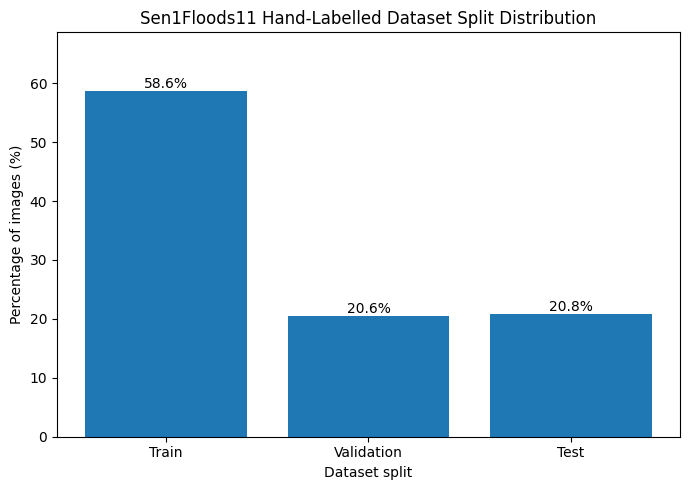

Dataset split percentages:
Train: 58.6% (251 images)
Validation: 20.6% (88 images)
Test: 20.8% (89 images)


In [ ]:
# Calculate number of images in each split
split_counts = {
    "Train": len(train),
    "Validation": len(valid),
    "Test": len(test)
}

# Convert counts to percentages
total_images = sum(split_counts.values())

split_percentages = {
    key: (value / total_images) * 100
    for key, value in split_counts.items()
}

# Plot histogram/bar chart
plt.figure(figsize=(7,5))

bars = plt.bar(
    split_percentages.keys(),
    split_percentages.values()
)

# Add percentage labels above bars
for bar, percentage in zip(bars, split_percentages.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylabel("Percentage of images (%)")
plt.xlabel("Dataset split")

plt.title(
    "Sen1Floods11 Hand-Labelled Dataset Split Distribution"
)

plt.ylim(0, max(split_percentages.values()) + 10)

plt.tight_layout()
plt.show()

# Print exact values
print("Dataset split percentages:")
for split, percentage in split_percentages.items():
    print(f"{split}: {percentage:.1f}% ({split_counts[split]} images)")

In [ ]:
#Check for data leakage:
#want to know whether the same flood event appears in both train and test.

def get_chip_ids(df):
    return set(
        df.iloc[:,0]
        .str.replace("_S1Hand.tif","", regex=False)
    )


train_ids = get_chip_ids(train)
valid_ids = get_chip_ids(valid)
test_ids = get_chip_ids(test)


print("Train-Validation chip overlap:",
      len(train_ids.intersection(valid_ids)))

print("Train-Test chip overlap:",
      len(train_ids.intersection(test_ids)))

print("Validation-Test chip overlap:",
      len(valid_ids.intersection(test_ids)))

Train-Validation chip overlap: 0
Train-Test chip overlap: 0
Validation-Test chip overlap: 0


To ensure no data leakage occurred, image chip identifiers were compared across the official training, validation, and test partitions. No duplicate chips were found between partitions, confirming that each satellite image appears exclusively in a single subset.

--------------------------

In [ ]:
import os

print("Searching for JRCPerm and S1Perm folders...\n")

for root, dirs, files in os.walk(DATA_DIR):
    for directory in dirs:
        if directory in ["JRCPerm", "S1Perm"]:
            print(os.path.join(root, directory))

Searching for JRCPerm and S1Perm folders...

/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data/perm_water/JRCPerm
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data/perm_water/S1Perm


In [ ]:

# Permanent Water Mask Files

import os
import glob

perm_water_dir = base_dir / "perm_water"

jrc_dir = os.path.join(perm_water_dir, "JRCPerm")
s1perm_dir = os.path.join(perm_water_dir, "S1Perm")

jrc_files = sorted(glob.glob(os.path.join(jrc_dir, "*.tif")))
s1perm_files = sorted(glob.glob(os.path.join(s1perm_dir, "*.tif")))

print("JRC permanent-water files:", len(jrc_files))
print("S1 permanent-water files:", len(s1perm_files))

print("\nFirst 10 JRC files:")
for f in jrc_files[:10]:
    print(os.path.basename(f))

print("\nFirst 10 S1Perm files:")
for f in s1perm_files[:10]:
    print(os.path.basename(f))

JRC permanent-water files: 814
S1 permanent-water files: 814

First 10 JRC files:
water_10_194_inhabited_167.78498987527377_-45.267540887186534.tif
water_10_194_inhabited_169.08472865033218_-44.627307617033836.tif
water_10_588_inhabited_-69.0890174214209_-16.10575129022326.tif
water_10_589_inhabited_-69.26971803251075_-15.653179287904821.tif
water_10_749_inhabited_85.60504168136961_48.73279303873935.tif
water_10_749_inhabited_88.83010435467857_48.38121967528145.tif
water_10_751_rural_85.61899420856585_28.867885787429604.tif
water_10_754_inhabited_78.37066301877482_32.969638941553384.tif
water_10_754_inhabited_78.51070554645935_33.89498267396236.tif
water_10_764_inhabited_100.26516132826785_50.88880407088885.tif

First 10 S1Perm files:
sentinel_10_194_inhabited_167.78498987527377_-45.267540887186534.tif
sentinel_10_194_inhabited_169.08472865033218_-44.627307617033836.tif
sentinel_10_588_inhabited_-69.0890174214209_-16.10575129022326.tif
sentinel_10_589_inhabited_-69.26971803251075_-15.6

In [ ]:

# Comparing One Sen1Floods11 Scene with Permanent Water Masks

import os
import glob
import rasterio

ar_files = sorted(glob.glob(
    str(base_dir / "**" / "*.tif"),
    recursive=True
))

print("Total .tif files found:", len(sar_files))

print("\nFirst 20 files:")
for f in sar_files[:20]:
    print(os.path.relpath(f, base_dir))

Total .tif files found: 21394

First 20 files:
flood_events/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_242570_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_290290_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_294583_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_312675_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_314919_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_360519_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_379434_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivia_432776_JRCWaterHand.tif
flood_events/HandLabeled/JRCWaterHand/Bolivi

In [ ]:
# Check JRCWaterHand masks for the hand-labelled scenes



jrc_hand_dir = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand"
)

jrc_hand_files = sorted(glob.glob(os.path.join(jrc_hand_dir, "*.tif")))

print("JRCWaterHand files:", len(jrc_hand_files))

print("\nFirst 20 JRCWaterHand files:")
for f in jrc_hand_files[:20]:
    print(os.path.basename(f))

test_scenes = [
    "India_772630",
    "India_570384",
    "Paraguay_1029042"
]

print("\nChecking our existing EDA scenes:")

for scene in test_scenes:
    expected_file = os.path.join(
        jrc_hand_dir,
        f"{scene}_JRCWaterHand.tif"
    )

    print(f"{scene}: {os.path.exists(expected_file)}")

JRCWaterHand files: 446

First 20 JRCWaterHand files:
Bolivia_103757_JRCWaterHand.tif
Bolivia_129334_JRCWaterHand.tif
Bolivia_195474_JRCWaterHand.tif
Bolivia_23014_JRCWaterHand.tif
Bolivia_233925_JRCWaterHand.tif
Bolivia_242570_JRCWaterHand.tif
Bolivia_290290_JRCWaterHand.tif
Bolivia_294583_JRCWaterHand.tif
Bolivia_312675_JRCWaterHand.tif
Bolivia_314919_JRCWaterHand.tif
Bolivia_360519_JRCWaterHand.tif
Bolivia_379434_JRCWaterHand.tif
Bolivia_432776_JRCWaterHand.tif
Bolivia_60373_JRCWaterHand.tif
Bolivia_76104_JRCWaterHand.tif
Ghana_103272_JRCWaterHand.tif
Ghana_1033830_JRCWaterHand.tif
Ghana_1078550_JRCWaterHand.tif
Ghana_1089161_JRCWaterHand.tif
Ghana_11745_JRCWaterHand.tif

Checking our existing EDA scenes:
India_772630: True
India_570384: True
Paraguay_1029042: True


In [ ]:

# Inspecting LabelHand and JRCWaterHand for One Scene


scene = "India_772630"

# Paths
label_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "LabelHand",
    f"{scene}_LabelHand.tif"
)

jrc_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand",
    f"{scene}_JRCWaterHand.tif"
)

#  two masks
with rasterio.open(label_path) as src:
    label = src.read(1)
    label_meta = src

with rasterio.open(jrc_path) as src:
    jrc = src.read(1)
    jrc_meta = src


print("LABELHAND")
print("Shape:", label.shape)
print("CRS:", label_meta.crs)
print("Transform:", label_meta.transform)
print("Bounds:", label_meta.bounds)
print("Unique values:", np.unique(label))

print("\nJRC WATER HAND")
print("Shape:", jrc.shape)
print("CRS:", jrc_meta.crs)
print("Transform:", jrc_meta.transform)
print("Bounds:", jrc_meta.bounds)
print("Unique values:", np.unique(jrc))


print("\nALIGNMENT CHECK")
print("Same shape:", label.shape == jrc.shape)
print("Same CRS:", label_meta.crs == jrc_meta.crs)
print("Same transform:", label_meta.transform == jrc_meta.transform)
print("Same bounds:", label_meta.bounds == jrc_meta.bounds)

LABELHAND
Shape: (512, 512)
CRS: EPSG:4326
Transform: | 0.00, 0.00, 93.00|
| 0.00,-0.00, 27.23|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=92.99934742987124, bottom=27.18230184522942, right=93.04534117241816, top=27.228295587776344)
Unique values: [-1  0  1]

JRC WATER HAND
Shape: (512, 512)
CRS: EPSG:4326
Transform: | 0.00, 0.00, 93.00|
| 0.00,-0.00, 27.23|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=92.99934742987122, bottom=27.18230184522942, right=93.04534117241815, top=27.228295587776344)
Unique values: [0]

ALIGNMENT CHECK
Same shape: True
Same CRS: True
Same transform: False
Same bounds: False


In [ ]:

# Checks for JRC Permanent Water Across Multiple Scenes



label_dir = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "LabelHand"
)

jrc_dir = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand"
)

# Get all LabelHand scenes
label_files = sorted(glob.glob(os.path.join(label_dir, "*.tif")))

results = []

for label_path in label_files:

    # Extract scene name
    filename = os.path.basename(label_path)
    scene = filename.replace("_LabelHand.tif", "")

    jrc_path = os.path.join(
        jrc_dir,
        f"{scene}_JRCWaterHand.tif"
    )

    # Skip if matching JRC mask does not exist
    if not os.path.exists(jrc_path):
        continue

    # Read both masks
    with rasterio.open(label_path) as label_src:
        label = label_src.read(1)

    with rasterio.open(jrc_path) as jrc_src:
        jrc = jrc_src.read(1)

    # Valid LabelHand pixels
    valid = label != -1

    # Unique JRC values
    jrc_values = np.unique(jrc)

    # Number of JRC permanent-water pixels Assuming 1 represents permanent water
    jrc_water_pixels = np.sum((jrc == 1) & valid)

    # Number of valid pixels
    valid_pixels = np.sum(valid)

    # Percentage permanent water
    jrc_water_percent = (
        jrc_water_pixels / valid_pixels * 100
        if valid_pixels > 0 else np.nan
    )

    results.append({
        "scene": scene,
        "jrc_unique_values": str(jrc_values),
        "jrc_water_pixels": jrc_water_pixels,
        "jrc_water_percent": jrc_water_percent
    })

jrc_results = pd.DataFrame(results)

print("Scenes checked:", len(jrc_results))

print("\nJRC unique values found:")
print(jrc_results["jrc_unique_values"].value_counts())

print("\nScenes containing JRC permanent water:")
print((jrc_results["jrc_water_pixels"] > 0).sum())

print("\nScenes with no JRC permanent water:")
print((jrc_results["jrc_water_pixels"] == 0).sum())

print("\nJRC permanent-water percentage summary:")
print(jrc_results["jrc_water_percent"].describe())

print("\nTop 20 scenes by JRC permanent-water percentage:")
print(
    jrc_results
    .sort_values("jrc_water_percent", ascending=False)
    .head(20)
    .to_string(index=False)
)

Scenes checked: 446

JRC unique values found:
jrc_unique_values
[0 1]    233
[0]      213
Name: count, dtype: int64

Scenes containing JRC permanent water:
228

Scenes with no JRC permanent water:
218

JRC permanent-water percentage summary:
count    441.000000
mean       3.241257
std       10.776800
min        0.000000
25%        0.000000
50%        0.003567
75%        0.573605
max       97.740936
Name: jrc_water_percent, dtype: float64

Top 20 scenes by JRC permanent-water percentage:
           scene jrc_unique_values  jrc_water_pixels  jrc_water_percent
Sri-Lanka_534068             [0 1]            256222          97.740936
Sri-Lanka_845821             [0 1]            233982          97.185556
   Spain_5923267             [0 1]            196405          89.788016
   Mekong_596495             [0 1]            144752          63.077164
    Ghana_866994             [0 1]             69450          59.100850
   Spain_5650136             [0 1]             91714          53.447633
    

Valid pixels: 223004
LabelHand water pixels: 61197
JRC permanent-water pixels: 46794
Water pixels remaining after removing permanent water: 14796

Percentages of valid pixels:
LabelHand water: 27.442108661728042
JRC permanent water: 20.983480116948574
Potential temporary water: 6.634858567559326

Overlap:
Permanent water that is also LabelHand water: 46401
Permanent water NOT labelled as water by LabelHand: 393


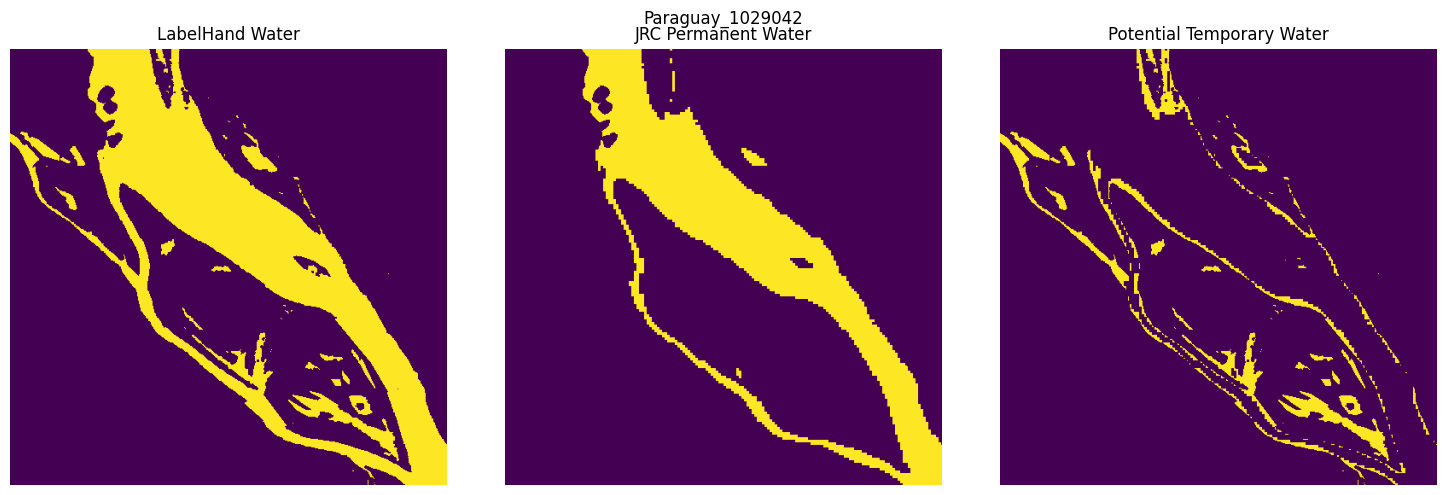

In [ ]:

#  comparison of LabelHand and JRCWaterHand

import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

scene = "Paraguay_1029042"

label_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "LabelHand",
    f"{scene}_LabelHand.tif"
)

jrc_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand",
    f"{scene}_JRCWaterHand.tif"
)

with rasterio.open(label_path) as src:
    label = src.read(1)

with rasterio.open(jrc_path) as src:
    jrc = src.read(1)

#  masks
valid = label != -1
water = (label == 1) & valid
permanent = (jrc == 1) & valid

# Potential temporary water
temporary = water & ~permanent


print("Valid pixels:", valid.sum())
print("LabelHand water pixels:", water.sum())
print("JRC permanent-water pixels:", permanent.sum())
print("Water pixels remaining after removing permanent water:", temporary.sum())

print("\nPercentages of valid pixels:")
print("LabelHand water:",
      water.sum() / valid.sum() * 100)

print("JRC permanent water:",
      permanent.sum() / valid.sum() * 100)

print("Potential temporary water:",
      temporary.sum() / valid.sum() * 100)

print("\nOverlap:")
print("Permanent water that is also LabelHand water:",
      (permanent & water).sum())

print("Permanent water NOT labelled as water by LabelHand:",
      (permanent & ~water).sum())


# Plot


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(water)
axes[0].set_title("LabelHand Water")
axes[0].axis("off")

axes[1].imshow(permanent)
axes[1].set_title("JRC Permanent Water")
axes[1].axis("off")

axes[2].imshow(temporary)
axes[2].set_title("Potential Temporary Water")
axes[2].axis("off")

plt.suptitle(scene)
plt.tight_layout()
plt.show()

In [ ]:

# Comparing the Original Water Extent with JRC-Adjusted Extent Across All 446 Hand-Labelled Scenes


label_dir = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "LabelHand"
)

jrc_dir = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand"
)

label_files = sorted(glob.glob(os.path.join(label_dir, "*.tif")))

results = []

for label_path in label_files:

    scene = os.path.basename(label_path).replace(
        "_LabelHand.tif", ""
    )

    jrc_path = os.path.join(
        jrc_dir,
        f"{scene}_JRCWaterHand.tif"
    )

    if not os.path.exists(jrc_path):
        continue

    with rasterio.open(label_path) as src:
        label = src.read(1)

    with rasterio.open(jrc_path) as src:
        jrc = src.read(1)

    # Valid pixels
    valid = label != -1

    # Water according to LabelHand
    water = (label == 1) & valid

    # Permanent water according to JRC
    permanent = (jrc == 1) & valid

    # Potential temporary flood water
    temporary = water & ~permanent

    # Counts
    valid_pixels = valid.sum()
    water_pixels = water.sum()
    permanent_pixels = permanent.sum()
    temporary_pixels = temporary.sum()
    overlap_pixels = (water & permanent).sum()

    # Percentages
    water_percent = water_pixels / valid_pixels * 100
    permanent_percent = permanent_pixels / valid_pixels * 100
    temporary_percent = temporary_pixels / valid_pixels * 100

    # How much JRC water overlaps LabelHand water?
    if permanent_pixels > 0:
        jrc_overlap_percent = (
            overlap_pixels / permanent_pixels * 100
        )
    else:
        jrc_overlap_percent = np.nan

    # How much LabelHand water remains after removing
    # permanent water?
    if water_pixels > 0:
        remaining_water_percent = (
            temporary_pixels / water_pixels * 100
        )
    else:
        remaining_water_percent = np.nan

    results.append({
        "scene": scene,
        "valid_pixels": valid_pixels,
        "water_pixels": water_pixels,
        "permanent_pixels": permanent_pixels,
        "temporary_pixels": temporary_pixels,
        "water_extent_percent": water_percent,
        "permanent_extent_percent": permanent_percent,
        "temporary_extent_percent": temporary_percent,
        "jrc_overlap_percent": jrc_overlap_percent,
        "remaining_water_percent": remaining_water_percent
    })

extent_comparison = pd.DataFrame(results)

print("Scenes analysed:", len(extent_comparison))

print("\n--- Original water extent ---")
print(extent_comparison["water_extent_percent"].describe())

print("\n--- JRC permanent-water extent ---")
print(extent_comparison["permanent_extent_percent"].describe())

print("\n--- JRC-adjusted temporary-water extent ---")
print(extent_comparison["temporary_extent_percent"].describe())

print("\n--- JRC overlap with LabelHand water ---")
print(extent_comparison["jrc_overlap_percent"].describe())

print("\n--- Percentage of LabelHand water remaining ---")
print(extent_comparison["remaining_water_percent"].describe())

print("\n--- Largest reductions in extent ---")

extent_comparison["extent_reduction"] = (
    extent_comparison["water_extent_percent"]
    - extent_comparison["temporary_extent_percent"]
)

print(
    extent_comparison[
        [
            "scene",
            "water_extent_percent",
            "permanent_extent_percent",
            "temporary_extent_percent",
            "extent_reduction"
        ]
    ]
    .sort_values("extent_reduction", ascending=False)
    .head(20)
    .to_string(index=False)
)

/var/folders/xh/8m4bc5md4rb_gzhj0jcjvbj40000gn/T/ipykernel_28443/4247930863.py:72: RuntimeWarning: invalid value encountered in scalar divide
  water_percent = water_pixels / valid_pixels * 100
/var/folders/xh/8m4bc5md4rb_gzhj0jcjvbj40000gn/T/ipykernel_28443/4247930863.py:73: RuntimeWarning: invalid value encountered in scalar divide
  permanent_percent = permanent_pixels / valid_pixels * 100
/var/folders/xh/8m4bc5md4rb_gzhj0jcjvbj40000gn/T/ipykernel_28443/4247930863.py:74: RuntimeWarning: invalid value encountered in scalar divide
  temporary_percent = temporary_pixels / valid_pixels * 100


Scenes analysed: 446

--- Original water extent ---
count    441.000000
mean      10.870678
std       19.146286
min        0.000000
25%        0.542687
50%        2.567673
75%       11.291142
max      100.000000
Name: water_extent_percent, dtype: float64

--- JRC permanent-water extent ---
count    441.000000
mean       3.241257
std       10.776800
min        0.000000
25%        0.000000
50%        0.003567
75%        0.573605
max       97.740936
Name: permanent_extent_percent, dtype: float64

--- JRC-adjusted temporary-water extent ---
count    441.000000
mean       7.774809
std       14.822287
min        0.000000
25%        0.464673
50%        1.907040
75%        7.211685
max      100.000000
Name: temporary_extent_percent, dtype: float64

--- JRC overlap with LabelHand water ---
count    228.000000
mean      87.574681
std       22.191122
min        0.000000
25%       88.541667
50%       96.534463
75%       99.409111
max      100.000000
Name: jrc_overlap_percent, dtype: float64

--- P

In [ ]:
# Verify JRCWaterHand metadata, alignment and nodata

scene = "Paraguay_1029042"

label_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "LabelHand",
    f"{scene}_LabelHand.tif"
)

jrc_path = os.path.join(
    base_dir,
    "flood_events",
    "HandLabeled",
    "JRCWaterHand",
    f"{scene}_JRCWaterHand.tif"
)

with rasterio.open(label_path) as label_src:
    
    label = label_src.read(1)
    
    label_shape = label_src.shape
    label_crs = label_src.crs
    label_transform = label_src.transform
    label_bounds = label_src.bounds
    label_nodata = label_src.nodata
    label_dtype = label_src.dtypes[0]

with rasterio.open(jrc_path) as jrc_src:
    
    jrc = jrc_src.read(1)
    
    jrc_shape = jrc_src.shape
    jrc_crs = jrc_src.crs
    jrc_transform = jrc_src.transform
    jrc_bounds = jrc_src.bounds
    jrc_nodata = jrc_src.nodata
    jrc_dtype = jrc_src.dtypes[0]
    
    jrc_tags = jrc_src.tags()

print("LABELHAND")
print("Shape:", label_shape)
print("CRS:", label_crs)
print("Transform:", label_transform)
print("Bounds:", label_bounds)
print("NoData:", label_nodata)
print("Data type:", label_dtype)

print("\nJRCWATERHAND")
print("Shape:", jrc_shape)
print("CRS:", jrc_crs)
print("Transform:", jrc_transform)
print("Bounds:", jrc_bounds)
print("NoData:", jrc_nodata)
print("Data type:", jrc_dtype)

print("\nJRC tags:")
print(jrc_tags)


print("\nALIGNMENT")

print(
    "Same shape:",
    label_shape == jrc_shape
)

print(
    "Same CRS:",
    label_crs == jrc_crs
)

print(
    "Transforms approximately equal:",
    np.allclose(
        np.array(label_transform),
        np.array(jrc_transform),
        rtol=0,
        atol=1e-12
    )
)

print(
    "Bounds approximately equal:",
    np.allclose(
        np.array(label_bounds),
        np.array(jrc_bounds),
        rtol=0,
        atol=1e-12
    )
)


# Value information

print("\nVALUES")

print("LabelHand unique values:", np.unique(label))
print("JRC unique values:", np.unique(jrc))

print("\nJRC value counts:")

unique, counts = np.unique(jrc, return_counts=True)

for value, count in zip(unique, counts):
    print(f"Value {value}: {count:,} pixels")

LABELHAND
Shape: (512, 512)
CRS: EPSG:4326
Transform: | 0.00, 0.00,-57.22|
| 0.00,-0.00,-24.28|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-57.21621572836786, bottom=-24.330689807320415, right=-57.17022198582094, top=-24.284696064773495)
NoData: None
Data type: int16

JRCWATERHAND
Shape: (512, 512)
CRS: EPSG:4326
Transform: | 0.00, 0.00,-57.22|
| 0.00,-0.00,-24.28|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-57.21621572836786, bottom=-24.330689807320415, right=-57.17022198582094, top=-24.284696064773495)
NoData: None
Data type: uint8

JRC tags:
{'OVR_RESAMPLING_ALG': 'NEAREST', 'AREA_OR_POINT': 'Area'}

ALIGNMENT
Same shape: True
Same CRS: True
Transforms approximately equal: True
Bounds approximately equal: True

VALUES
LabelHand unique values: [-1  0  1]
JRC unique values: [0 1]

JRC value counts:
Value 0: 213,101 pixels
Value 1: 49,043 pixels


Scene: Paraguay_1029042
Valid pixels: 223,004
LabelHand water pixels: 61,197
JRC permanent-water pixels: 46,794
Event-associated water pixels: 14,796

LabelHand water extent: 27.44%
JRC permanent-water extent: 20.98%
JRC-adjusted event-associated extent: 6.63%


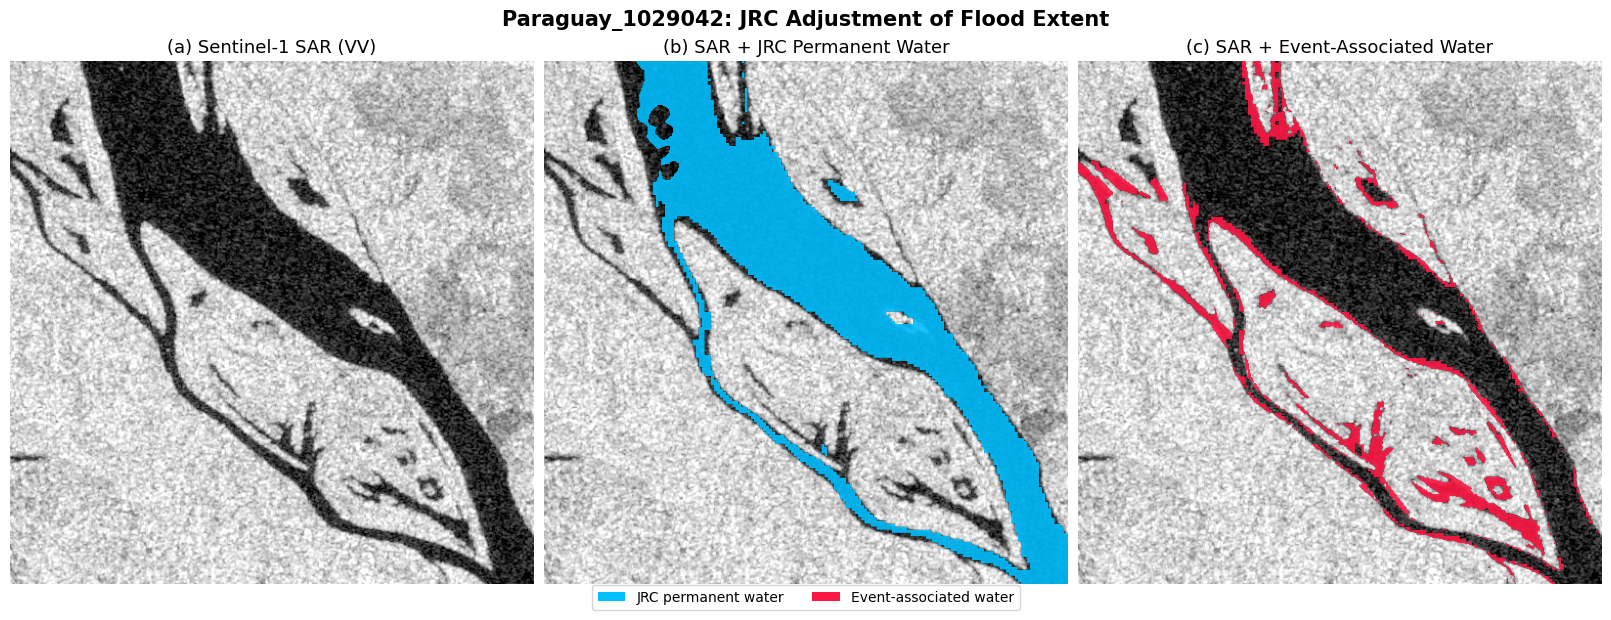


Figure saved to:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Paraguay_1029042_JRC_Adjustment.png


In [ ]:

# JRC PERMANENT WATER / EVENT-ASSOCIATED WATER FIGURE
# Paraguay_1029042

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap


# 1. Define scene and file paths

scene = "Paraguay_1029042"

base_dir = DATA_DIR / "v1.1" / "data" / "flood_events" / "HandLabeled"

s1_path = f"{base_dir}/S1Hand/{scene}_S1Hand.tif"
label_path = f"{base_dir}/LabelHand/{scene}_LabelHand.tif"
jrc_path = f"{base_dir}/JRCWaterHand/{scene}_JRCWaterHand.tif"


# 2. Load the Sentinel-1 SAR


with rasterio.open(s1_path) as src:
    sar = src.read()

# Sentinel-1 contains two bands:
# Band 1 = VV
# Band 2 = VH

vv = sar[0]

# 3. Load LabelHand

with rasterio.open(label_path) as src:
    label = src.read(1)



# 4. Load JRC permanent-water mask
with rasterio.open(jrc_path) as src:
    jrc = src.read(1)


# 5.  masks

# Valid LabelHand pixels
valid_mask = label != -1

# Water identified by LabelHand
water_mask = (label == 1) & valid_mask

# Permanent water identified by JRC
permanent_mask = (jrc == 1) & valid_mask

# Event-associated water:
# LabelHand water that is NOT identified as permanent water
event_water_mask = (
    (label == 1) &
    (jrc == 0) &
    valid_mask
)



# 6. Calc. statistics for verification
valid_pixels = np.sum(valid_mask)

label_water_pixels = np.sum(water_mask)

jrc_permanent_pixels = np.sum(permanent_mask)

event_water_pixels = np.sum(event_water_mask)


print(f"Scene: {scene}")
print(f"Valid pixels: {valid_pixels:,}")
print(f"LabelHand water pixels: {label_water_pixels:,}")
print(f"JRC permanent-water pixels: {jrc_permanent_pixels:,}")
print(f"Event-associated water pixels: {event_water_pixels:,}")

print()

print(
    f"LabelHand water extent: "
    f"{label_water_pixels / valid_pixels * 100:.2f}%"
)

print(
    f"JRC permanent-water extent: "
    f"{jrc_permanent_pixels / valid_pixels * 100:.2f}%"
)

print(
    f"JRC-adjusted event-associated extent: "
    f"{event_water_pixels / valid_pixels * 100:.2f}%"
)



# 7.  SAR visualisation

# Ignore extreme SAR values when displaying the image so
# the majority of spatial detail is easier to see.

vmin = np.nanpercentile(vv, 2)
vmax = np.nanpercentile(vv, 98)


# 8. figure

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    constrained_layout=True
)

# Panel A - Sentinel-1 SAR

axes[0].imshow(
    vv,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title(
    "(a) Sentinel-1 SAR (VV)",
    fontsize=13
)

axes[0].axis("off")


# Panel B - SAR + JRC Permanent Water

axes[1].imshow(
    vv,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

# Mask everything except permanent water
permanent_overlay = np.ma.masked_where(
    ~permanent_mask,
    permanent_mask
)

axes[1].imshow(
    permanent_overlay,
    cmap=ListedColormap(["#00BFFF"]),   # bright cyan-blue
    alpha=0.90
)

axes[1].set_title(
    "(b) SAR + JRC Permanent Water",
    fontsize=13
)

axes[1].axis("off")


# Panel C - SAR + Event-Associated Water
axes[2].imshow(
    vv,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

# Mask everything except event-associated water
event_overlay = np.ma.masked_where(
    ~event_water_mask,
    event_water_mask
)

axes[2].imshow(
    event_overlay,
    cmap=ListedColormap(["#FF1744"]),   # bright red
    alpha=0.90
)

axes[2].set_title(
    "(c) SAR + Event-Associated Water",
    fontsize=13
)

axes[2].axis("off")


# 9 legend

legend_elements = [
    Patch(
        facecolor="#00BFFF",
        edgecolor="none",
        label="JRC permanent water"
    ),
    Patch(
        facecolor="#FF1744",
        edgecolor="none",
        label="Event-associated water"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)
# 10.  title

fig.suptitle(
    "Paraguay_1029042: JRC Adjustment of Flood Extent",
    fontsize=15,
    fontweight="bold"
)



# 11. Save

output_path = (
    PROJECT_DIR
    / "results_new"
    / "figures"
    / "qualitative"
    / "Paraguay_1029042_JRC_Adjustment.png"
)

output_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print(f"Figure saved to:\n{output_path}")